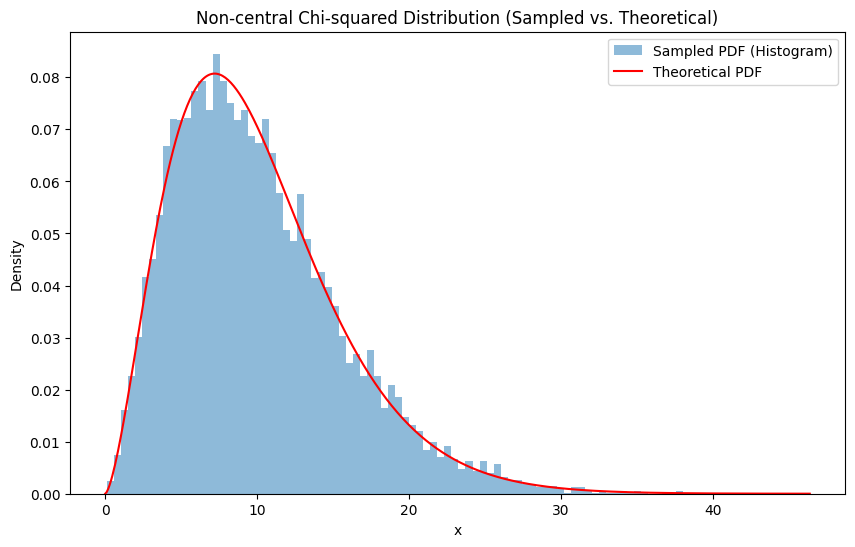

In [166]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ncx2

# Parameters
k = 5  # degrees of freedom
lambda_param = 5  # non-centrality parameter
sample_size = 10000

# Generate samples
samples = ncx2.rvs(k, lambda_param, size=sample_size)

# Create histogram
hist, bins = np.histogram(samples, bins=100, density=True)
bin_centers = (bins[:-1] + bins[1:]) / 2

# Theoretical PDF
x = np.linspace(0, max(samples), 500)
theoretical_pdf = ncx2.pdf(x, k, lambda_param)

# Plot
plt.figure(figsize=(10, 6))
plt.hist(samples, bins=100, density=True, alpha=0.5, label='Sampled PDF (Histogram)')
plt.plot(x, theoretical_pdf, 'r-', label='Theoretical PDF')
plt.xlabel('x')
plt.ylabel('Density')
plt.title('Non-central Chi-squared Distribution (Sampled vs. Theoretical)')
plt.legend()
plt.show()

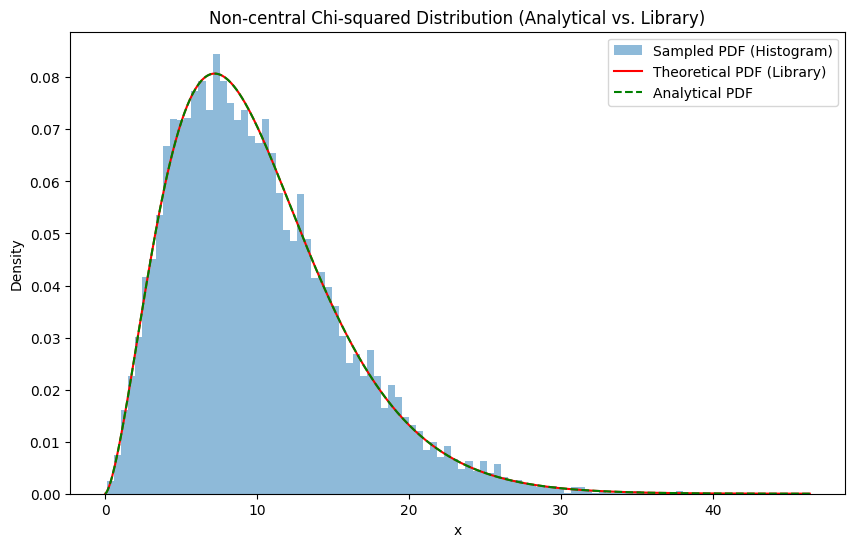

In [167]:
from scipy.special import iv

# Analytical PDF
def analytical_pdf(x, k, lambda_param):
    bessel_term = iv(k / 2 - 1, np.sqrt(lambda_param * x))
    pdf = 0.5 * np.exp(-(x + lambda_param) / 2) * ((x / lambda_param) ** (k / 4 - 0.5)) * bessel_term
    return pdf

# Analytical PDF values
analytical_values = analytical_pdf(x, k, lambda_param)

# Plot
plt.figure(figsize=(10, 6))
plt.hist(samples, bins=100, density=True, alpha=0.5, label='Sampled PDF (Histogram)')
plt.plot(x, theoretical_pdf, 'r-', label='Theoretical PDF (Library)')
plt.plot(x, analytical_values, 'g--', label='Analytical PDF')
plt.xlabel('x')
plt.ylabel('Density')
plt.title('Non-central Chi-squared Distribution (Analytical vs. Library)')
plt.legend()
plt.show()



/var/folders/0n/dlqrxfs51z323nydqrvvj75c0000gn/T/ipykernel_18875/3337641107.py:28: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  fn /= np.trapz(fn, x)  # Normalize the PDF


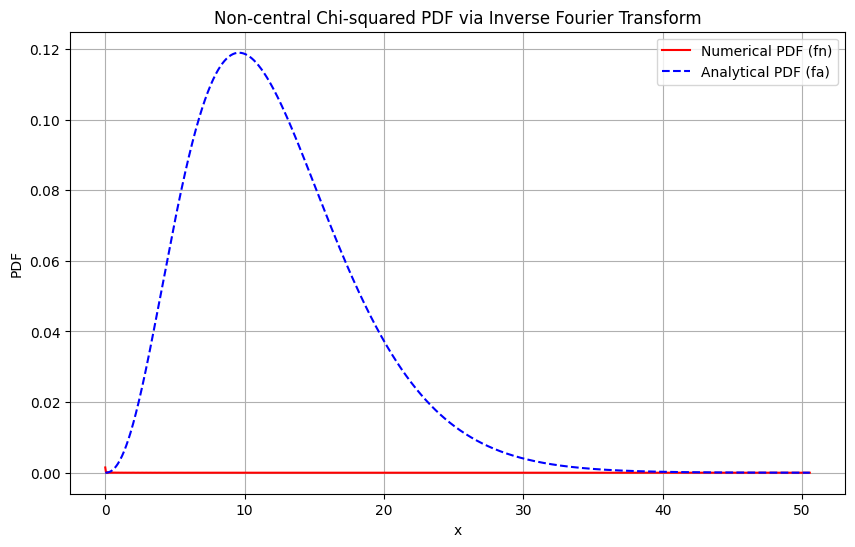

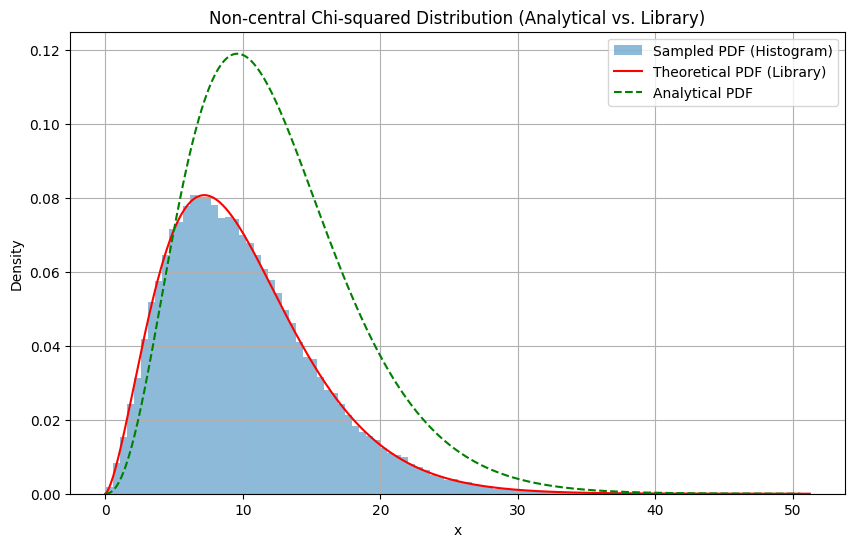

In [168]:
# Import necessary libraries
import numpy as np
from numpy.fft import fft, ifft, fftshift, ifftshift
import matplotlib.pyplot as plt
from scipy.special import iv
from scipy.stats import ncx2

# Parameters
N = 2024
Dx = 0.05
Lx = N * Dx
x = Dx * np.arange(-N/2, N/2)
Dxi = 2 * np.pi / Lx
xi = Dxi * np.arange(-N/2, N/2)

k = 5  # degrees of freedom
lambda_ = 5  # non-centrality parameter

# Correct characteristic function Fa(xi)
Fa = np.exp(-lambda_ / (1 - 2j * xi)) / (1 - 2j * xi) ** (k / 2)

# Compute the inverse Fourier transform to get the PDF (fn)
fn = fftshift(ifft(ifftshift(Fa))) / Dx

# Take the real part and normalize
fn = np.real(fn)
fn[fn < 0] = 0  # Remove negative values due to numerical errors
fn /= np.trapz(fn, x)  # Normalize the PDF

# Since the PDF is defined for x >= 0, select x >= 0
indices = x >= 0
x_pos = x[indices]
fn_pos = fn[indices]

# Analytical PDF
def analytical_pdf(x, k, lambda_):
    pdf = np.zeros_like(x)
    x_pos = x[x >= 0]
    sqrt_lambda_x = np.sqrt(lambda_ * x_pos)
    bessel_term = iv(k / 2 - 1, sqrt_lambda_x)
    pdf_pos = (
        0.5
        * np.exp(-0.5 * (x_pos + lambda_))
        * (x_pos / lambda_) ** (k / 2 - 1)
        * bessel_term
    )
    pdf[x >= 0] = pdf_pos
    return pdf

analytical_values = analytical_pdf(x, k, lambda_)

# Generate samples for histogram
sample_size = 100000
samples = ncx2.rvs(k, lambda_, size=sample_size)
hist, bins = np.histogram(samples, bins=100, density=True)
bin_centers = 0.5 * (bins[1:] + bins[:-1])

# Theoretical PDF from scipy.stats
x_pdf = np.linspace(0, np.max(samples), 1000)
theoretical_pdf = ncx2.pdf(x_pdf, k, lambda_)

# Plot the numerical and analytical PDFs
plt.figure(figsize=(10, 6))
plt.plot(x_pos, fn_pos, linestyle='-', color="r", label='Numerical PDF (fn)')
plt.plot(
    x_pos, analytical_values[indices], linestyle='--', color="b", label='Analytical PDF (fa)'
)
plt.xlabel('x')
plt.ylabel('PDF')
plt.legend()
plt.title('Non-central Chi-squared PDF via Inverse Fourier Transform')
plt.grid(True)
plt.show()

# Plot the sampled histogram and theoretical PDF
plt.figure(figsize=(10, 6))
plt.hist(samples, bins=100, density=True, alpha=0.5, label='Sampled PDF (Histogram)')
plt.plot(x_pdf, theoretical_pdf, 'r-', label='Theoretical PDF (Library)')
plt.plot(
    x_pos, analytical_values[indices], 'g--', label='Analytical PDF'
)
plt.xlabel('x')
plt.ylabel('Density')
plt.title('Non-central Chi-squared Distribution (Analytical vs. Library)')
plt.legend()
plt.grid(True)
plt.show()